# **Fundamentals of arbitrage and options**
*Change of measure: why???*
---
 <br>
 
- Copyright (c) Antoine (Jack) Jacquier, 2026. All rights reserved

- Author: Antoine (Jack) Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.13.5

In [1]:
from platform import python_version
print("Current python version: ", python_version())

Current python version:  3.13.5


$$\newcommand{\PP}{\mathbb{P}}$$
$$\newcommand{\QQ}{\mathbb{Q}}$$
$$\newcommand{\RR}{\mathbb{R}}$$
$$\newcommand{\EE}{\mathbb{E}}$$
$$\newcommand{\VV}{\mathbb{V}}$$
$$\newcommand{\D}{\mathrm{d}}$$
$$\newcommand{\E}{\mathrm{e}}$$
$$\newcommand{\Call}{\mathrm{C}}$$
$$\newcommand{\B}{\mathrm{B}}$$
$$\newcommand{\P}{\mathrm{P}}$$
$$\newcommand{\Diff}{\mathrm{D}}$$

## Session Overview

- Types of financial markets and traded assets and derivatives
- `python`
- Fundamental concept of arbitrage
- Pricing derivatives by replication

# Financial markets
*What exactly are we trying to describe on financial markets?*

*What are we talking about when we talk about derivatives, pricing, hedging, arbitrage?*

## Underlying securities

### Single stocks

The basis of financial markets is the limited liability company (Ltd), whereby companies are owned by their shareholders; 
the shares provide partial ownership and have a value reflecting the company's value.
The shares are quoted and traded on stock exchanges.

- https://finance.yahoo.com/quote/KO/
- https://finance.yahoo.com/quote/TCEHY?p=TCEHY&.tsrc=fin-srch
- https://finance.yahoo.com/quote/DEO/

### Indices

- https://uk.finance.yahoo.com/quote/%5EGSPC?p=%5EGSPC
- https://uk.finance.yahoo.com/quote/%5EFTSE?p=%5EFTSE
- https://uk.finance.yahoo.com/quote/%5EN225?p=%5EN225
- https://www.eiopa.europa.eu/tools-and-data/catastrophe-data-hub_en

### Commodities

- https://finance.yahoo.com/quote/GC=F/


### Interest rates

Interest rates are set by national, state and local governments to finance their economic activities.

- https://finance.yahoo.com/quote/%5ETNX/

### Exchange rates

Fixed vs floating exchange rates. 

*Example: Gold standard*

- https://uk.finance.yahoo.com/quote/GBPEUR%3DX?p=GBPEUR%3DX
- https://uk.finance.yahoo.com/quote/GBPUSD%3DX?p=GBPUSD%3DX
- https://uk.finance.yahoo.com/quote/GBPCNY%3DX?p=GBPCNY%3DX

### Cryptocurrencies

- https://uk.finance.yahoo.com/quote/BTC-GBP?p=BTC-GBP
- https://uk.finance.yahoo.com/quote/ETH-GBP?p=ETH-GBP


## Derivative securities / Contingent claims

**Definition:
A derivative security (or contingent claim) is a financial contract whose value at expiry $T$ is fully determined by the price of the underlying before and up to time $T$.**

According to the Bank for International Settlements, in the first half of 2019, 
the total notional outstanding for contracts in the derivatives market was around USD$640$ trillion. 

We say that an investor is **long** (**short**) in a position on an asset if she **bought** (**sold**) the asset. *A long investor therefore benefits from the asset price increasing while the short investor benefits when the asset price drops.


### Forward contracts

**Definition: A forward contract is an agreement to buy or sell an asset $S$ at some future time T for a given price K.**

A trader is said to be long the forward if she agrees to buy the underlying and short if she agrees to sell it.

- https://www.sec.gov/Archives/edgar/data/75488/000095015720000709/ex10-3.htm

$K = 100$, $T = 1$ year, $S_T = 90$

### Options

- A European Call option gives its owner the right (but not the obligation) to buy an underlying $S$ at maturity $T$ for a given price (strike) $K$. Its payoff at $T$ is
$$
\text{European Call Payoff}: \max(S_T - K, 0) =: (S_T - K)_+.
$$

- A European Put option gives its owner the right (but not the obligation) to sell an underlying $S$ at maturity $T$ for a given price (strike) $K$. Its payoff at $T$ is
$$
\text{European Put Payoff}: \max(K-S_T, 0) =: (K-S_T)_+.
$$

- An American Call (respectively Put) option gives its owner the right (but not the obligation) to buy (respectively sell) an underlying $S$ at any time before maturity $T$ for a given price (strike) $K$.

- An Asian option has payoff
\begin{align*}
\text{Asian Call Payoff}: \qquad & \qquad (A_T - K)_+,\\
\text{Asian Put Payoff}:  \qquad & \qquad (K - A_T)_+,
\end{align*}
where 
$$
A_T := \frac{1}{T}\int_{0}^{T}S_u\D u.
$$

Example: https://www.cboe.com/delayed_quotes/spy/quote_table

*Question: As an investor, what is more risky? Being long a Call or long a forward (with same maturity and same strike)?*

### Swaps

**Definition: A swap is an agreement to exchange two quantities at some future date.**

- https://www.sec.gov/Archives/edgar/data/1508478/000119312511077213/dex1015.htm
- https://www.sec.gov/Archives/edgar/data/70858/000119312512021960/d288901d424b2.htm

## Markets

- Organised exchanges (https://www.cboe.com/) give more guarantees in terms of liquidity, standardisation, transparency

- Over-The-Counter (OTC), directly between two parties.

# ARBITRAGE or *how to evaluate the price of a contingent claim?*

## Modelling assumptions

- No market frictions (no transaction costs, no bid/ask spread, no taxes)
- No default risk (same interest for borrowing and lending)
- Competitive markets (market participants act as price takers, not price makers)
- Rational agents (market participants prefer more to less)
- No arbitrage

Financial markets involve riskless (bank account) and risky (stocks,....) assets. 
The only reason for the investor to expose herself to risk is the opportunity of greater profit.

## Creating an arbitrageable portfolio

Consider a portfolio consisting of some (risk-free) bond, some (risky) stock and some European Call option with strike $K$, in a one-time period setting:
$$
\Pi_t = n_B \B_t + n_S S_t + n_C \Call_t,
\qquad\text{for } t \in \{0,T\}.
$$
At time $0$, the prices of the bond, the underlying stock and the Call are given by $\B_0, S_0, \Call_0$.
At time $T=1$, the bond price has moved to $\B_1$ while the stock price has either gone up to $S_1^u$ or down to $S_1^d$.
Therefore, at maturity, the payoff of the Call option reads
\begin{align*}
\Call_T^u = (S_T^u-K)_+ = \max(S_T^u-K,0) \qquad\text{or}\qquad \Call_T^d = (S_T^d-K)_+ = \max(S_T^d-K, 0).
\end{align*}

In [2]:
import numpy as np

In [3]:
def portfolio_value(quantities, B, S, C, details):
    """
    Compute the value of a portfolio consisting of
    bond, stock, European Call option,
    in respective quantities quantities 
    and with respective values B, S, C
    """
    nB, nS, nC = quantities
    if details:
        print("Bond/Stock/Call amounts: ", 
              np.round(nB*B, 5), 
              np.round(nS*S, 5), 
              np.round(nC*C, 5))
    return np.round(nB*B + nS*S + nC*C, 5)

def callPayoff(S, K):
    return max(S-K, 0.)

In [4]:
### Initial values:
B0, S0, C0, K = 1., 1., .2, 1.

### Up and Down values for the stock price at time 1
Sd, Su = .75, 1.75

### Bond price at time 1
B1 = 1.25

Cd, Cu = callPayoff(Sd, K), callPayoff(Su, K)
print("At expiry, the Call price is worth %.2f in the Down state and %.2f in the Up state" %(Cd, Cu))

At expiry, the Call price is worth 0.00 in the Down state and 0.75 in the Up state


At maturity, the portfolio can take two different values, depending on the state (up or down).

In [5]:
### Quantities of the bond, stock and Call in the portfolio:
n_Bond1, n_Stock1, n_Call1 = 40, 40, 100

quantities_Ptf1 = [n_Bond1, n_Stock1, n_Call1]

print("Value of the portfolio at time zero:", portfolio_value(quantities_Ptf1, B0, S0, C0, False))

print("Value of the portfolio at expiry in the Down and the Up states:", 
      portfolio_value(quantities_Ptf1, B1, Sd, Cd, False), 
      portfolio_value(quantities_Ptf1, B1, Su, Cu, False))

Value of the portfolio at time zero: 100.0
Value of the portfolio at expiry in the Down and the Up states: 80.0 195.0


Let us now consider an alternative portfolio, i.e. on the same assets, but with different weights.

In [6]:
### Quantities of the bond, stock and Call in the new portfolio:
n_Bond2, n_Stock2, n_Call2 = 47.2, 28, 116
quantities_Ptf2 = n_Bond2, n_Stock2, n_Call2

print("New portfolio at time zero:", portfolio_value(quantities_Ptf2, B0, S0, C0, False))

print("New portfolio in down and up states at expiry:", 
      portfolio_value(quantities_Ptf2, B1, Sd, Cd, False),
      portfolio_value(quantities_Ptf2, B1, Su, Cu, False))

New portfolio at time zero: 98.4
New portfolio in down and up states at expiry: 80.0 195.0


**WHAT IS THE PROBLEM?**

Consider the difference of the two portfolios (itself a portfolio):
$$
\Diff = \P^{1} - \P^{2}.
$$

In [7]:
n_Bond = n_Bond1 - n_Bond2
n_Stock = n_Stock1 - n_Stock2
n_Call = n_Call1 - n_Call2

quantities = n_Bond, n_Stock, n_Call

print("Difference portfolio at time zero:", portfolio_value(quantities, B0, S0, C0, False))

print("Difference portfolio in the Down and Up states at expiry:", 
      portfolio_value(quantities, B1, Sd, Cd, False),
      portfolio_value(quantities, B1, Su, Cu, False))

print("Amount of bonds:   ", np.round(quantities[0], 1))
print("Amount of stocks:  ", quantities[1])
print("Amount of options: ", quantities[2])

Difference portfolio at time zero: 1.6
Difference portfolio in the Down and Up states at expiry: -0.0 -0.0
Amount of bonds:    -7.2
Amount of stocks:   12
Amount of options:  -16


*Question: What do you think?*

A closer look

In [8]:
print("Value of the difference portfolio 1 at time zero:", 
      portfolio_value(quantities, B0, S0, C0, True))

Bond/Stock/Call amounts:  -7.2 12.0 -3.2
Value of the difference portfolio 1 at time zero: 1.6


This corresponds to the position: sell stock, buy bond and option.

However, we can see that the position (sell stock, buy bond) is actually a perfect **hedge** for a long position in the Call option.

**--> Hedging and pricing by replication<--**

**No Arbitrage Definition: No profit is guaranteed without exposure to risk.**

## Pricing by replication (introducing probabilities)

- Fischer Black and Myron Scholes. <a href="https://www.journals.uchicago.edu/doi/10.1086/260062">"The Pricing of Options and Corporate Liabilities"</a>. Journal of Political Economy (1973). 
- Robert C. Merton. <a href="https://www.jstor.org/stable/3003143?origin=crossref">"Theory of Rational Option Pricing"</a>. Bell Journal of Economics and Management Science (1973).

Merton and Scholes got awarded the Nobel Memorial Prize in Economic Sciences "for a new method to determine the value of derivatives" in 1997.

**Meta-Theorem: Under no-arbitrage settings, two portfolios generating the same values in all states of the world should be equal at all times.**

*Question: If two quoted prices are different (say because of two different vendors on an OTC market), how can you benefit from it?*

Consider a bond with constant value equal to $1$ and a stock price with $S_0 = 10$ and
\begin{equation*}
\left\{
\begin{array}{ll}
S_1^u = 20, & \text{ with probability }p^u,\\
S_1^d = 7.5, & \text{ with probability }p^d,
\end{array}
\right.
\end{equation*}
for some $p^d,p^u \in [0,1]$ with $p^d + p^u = 1$.

**GOAL:** Determine the price of a European Call option on $S$ with maturity $T=1$ and strike $K=15$.

**STRATEGY**: Construct a portfolio $\Pi := n_B B + n_S S$ replicating exactly the option payoff.

Construct 

$$
\Diff := \Pi - \Call = n_B \B + n_S S + n_{C} \Call,
$$
with $n_C = -1$.

If $\Pi$ replicates $\Call$, i.e. $\Pi_T = \Call_T$ (in all states of the world),
then
$$
\Diff_T = 0.
$$

Remarks:
- The vector $(n_B, n_S)$ is called a strategy.
- What about the probabilities $p^d$ and $p^u$? Where do they come from?

**First Fundamental Theorem of Asset Pricing (FTAP):
No-arbitrage is equivalent to the existence of an equivalent martingale
measure.**


In other words, under no-arbitrage, we can find probabilities 
$\widetilde{p}^d, \widetilde{p}^u \in [0,1]$ with $\widetilde{p}^d + \widetilde{p}^u = 1$ such that
$$
S_0 = \widetilde{p}^d S_1^d + \widetilde{p}^u S_1^u = \widetilde{\EE}[S_1].
$$

## Constructing the martingale measure

Let $S$ denote a stock price, whose value at time $0$ is $S_0>0$.
At time $t_1>0$, the process can take two possible values:
$$
S_1=
\left\{
\begin{array}{rll}
uS_0, & \text{with probability } p,\\
dS_0, & \text{with probability } 1-p,
\end{array}
\right.
$$
where $0<d<u$ and $p\in(0,1)$.

*Note: Another way to understand this is to write $S_1=X S_0$, where $X$ is a Bernoulli random variable taking the value $u$ with probability $p$ and the value $d$ with probability $1-p$.*

We assume that a financial agent can invest (at time $t_0$) in both the asset $S$ and in a risk-free bond, 
i.e. borrow or sell money with a (non random) interest rate equal to $r\geq 0$ over the period $[t_0,t_1]$.
We are interested in determining the price $\Call_0$ at time $t_0$ of a European Call option with strike $K>0$ and maturity $t_1$.
At time $t_1$, the two possible payoffs (corresponding to the two different states of the world) are
$$
\Call_1^{u} := \left(uS_0-K\right)_+
\qquad\text{and}\qquad
\Call_1^{d} := \left(dS_0-K\right)_+.
$$
One may be tempted to value it at the price 
$$
\Call_0
 = \frac{\mathbb{E}_p[\Call_1]}{1+r}
 = \frac{p\Call_1^{u}+(1-p)\Call_1^{d}}{1+r}.
$$
However, this is in general false, since the probability $p$ has been chosen from the investor's point of view, 
and does not necessary reflect the market's point of view.
It turns out that this very probability $p$, called the historical (or physical) probability, does not appear at all in the pricing formula, 
as the following theorem shows.

**Theorem.
In the absence of arbitrage opportunities, the price at time $t_0$ (inception of the contract) of a European call option written on $S$, 
with strike $K$ and maturity $t_1$ is worth
$$
\Call_0 = \frac{\pi \Call_1^{u}+(1-\pi) \Call_1^{d}}{1+r} = \frac{\widetilde{\EE}[\Call_{1}]}{1+r},
\qquad\text{where }\pi:= \frac{1+r-d}{u-d}.
$$**
The probability $\pi$ is called the risk-neutral probability.
In the previous notations, this corresponds to $\widetilde{p}^{u} = \pi$
and $\widetilde{p}^{d} = 1-\pi$.

#### Proof

The proof is again based on pricing by replication, i.e. we want to construct a portfolio consisting of shares and risk-free bonds 
that exactly replicates (has the same payoff as) the option we wish to evaluate.
Consider a portfolio $\Pi$ consisting of an amount $\Delta$ of shares and with the notional $\phi$ invested in the risk-free bond.
The value at time $t_0$ of the portfolio is therefore 
$$
\Pi_0=\Delta S_0+\phi \B_0.
$$
At time $t_1$, it is worth
$$
\Pi_1 = \Delta S_1 + (1+r)\phi
 = 
\left\{
\begin{array}{rll}
\Delta uS_0 + (1+r)\phi, & \text{with probability } p,\\
\Delta dS_0 + (1+r)\phi, & \text{with probability } 1-p.
\end{array}
\right.
$$
Since our portfolio $\Pi$ has to replicate the option, it therefore needs to have the same payoff.
This implies the following system of equations:
$$
\left\{
\begin{array}{rl}
\Delta uS_0 + (1+r)\phi & = \Call_1^{u} = (uS_0-K)_+\\
\Delta dS_0 + (1+r)\phi & = \Call_1^{d} = (dS_0-K)_+,
\end{array}
\right.
$$
which we can solve explicitly as
$$
\Delta = \frac{\Call_1^{u} - \Call_1^{d}}{(u-d)S_0},
\qquad\text{and}\qquad
\phi = \frac{1}{1+r}\frac{u\Call_1^{d}-d\Call_1^{u}}{(u-d)}.
$$
By absence of arbitrage, since our portfolio $\Pi$ and the Call option have the same value at maturity (same payoff), 
then they necessarily have the same value at inception of the contract, i.e. at time $t_0$, 
so that $\Call_0=\Pi_0$.
Define now $\pi:=\displaystyle \frac{1+r-d}{u-d}$ and the theorem follows.

# Wrapping up in a more general (abstract) setup

The fundamental model of mathematical finance consists of a probability space $(\Omega, \mathcal{F},\PP)$
on which we define a random variable $S$.
The most obvious example is when $S$ takes values in $\RR$ or $\RR_+$
and represents the price of a stock (or an interest rate, the price of some commodity...) at some given time, 
or when it is $\RR^n$-valued ($n\in\mathbb{N}$) and accounts for the basket of share prices in an index such as the S\&P$500$.
One can also think of it as an infinite-dimensional random variable representing the whole path of a share price process between today and some future time, i.e. $S=(S_t)_{t\geq 0}$.

A financial derivative (contingent claim) written on $S$ can then be thought of as a functional $f(S)$.
Financial derivatives are usually classified according to whether $S$ represents the value of the share price at some future time $T>0$ 
(European options) or the whole trajectory between today (time zero) and time $T$ (American options).
One of the fundamental questions in mathematical finance is to evaluate such functionals, 
i.e. to determine at time zero (inception  of the contract) the expected value of $f(S)$. 
Intuitively speaking we wish to answer the following question: 
$$
\text{How much are we willing to pay today (time zero) to receive $f(S)$ at time $T$?}
$$

The answer lies in the concept of *absence of arbitrage*.
Consider a portfolio---or a trading strategy---as a random process $(\Pi_t^\theta)_{t\geq 0}$ consisting of some positions in
$n$ stock prices $S^{(1)},\ldots,S^{(n)}$:
$$
\Pi_t^\theta = \sum_{i=1}^n \theta_t^{(i)}S_{t}^{(i)},\qquad \text{for all }t\geq 0,
$$
where $\theta_{t}^{(i)}$ represents the quantity of stock $i$ in the portfolio at time $t$.
We have written here $\Pi_t^\theta$ to emphasise the fact that 
the strategy is fully determined by the (time-dependent) vector $\theta$.
In a discrete-time setting, let us fix some time $t>0$.
At time $t+1$, the investor may want to rebalance his portfolio, i.e. change its composition, and the value of the portfolio hence becomes
$$
\Pi_{t+1}^\theta = \sum_{i=1}^n \theta_{t+1}^{(i)}S_{t+1}^{(i)}.
$$
If we assume that the investor does not invest nor withdraw any amount from his portfolio, then we necessarily have
$$
\sum_{i=1}^n \theta_{t}^{(i)}S_{t+1}^{(i)}=\sum_{i=1}^n \theta_{t+1}^{(i)}S_{t+1}^{(i)}.
$$
This can be written equivalently
\begin{align*}
\Pi_{t+1}^\theta - \Pi_{t}^\theta
 & = \sum_{i=1}^n \theta_{t+1}^{(i)}S_{t+1}^{(i)} - \sum_{i=1}^n \theta_{t}^{(i)}S_{t}^{(i)}\\
 & = \sum_{i=1}^n \theta_{t}^{(i)}S_{t+1}^{(i)} - \sum_{i=1}^n \theta_{t}^{(i)}S_{t}^{(i)}\\
 & = \sum_{i=1}^n \theta_{t}^{(i)}\left(S_{t+1}^{(i)}-S_{t}^{(i)}\right),
\end{align*}
and we shall call such a portfolio *self-financing*.

We shall further call a trading strategy *admissible* if it is self-financing and if $\Pi_t^\theta\geq 0$ for all $t\geq 0$.

**Definition: An arbitrage is an admissible trading strategy (or a portfolio) $\Pi^\theta=\left(\Pi_t^\theta\right)_{t\geq 0}$ 
for which there exists some time $T>0$ such that
$$
\Pi_0^\theta=0 \text{ and }
\Pi_T^\theta\geq 0 \text{ almost surely}
\qquad\text{and}\qquad
\PP\left(\Pi_T^\theta>0\right)>0.
$$**

Intuitively the concept *absence of arbitrage* therefore means that one cannot make a sure profit out of nothing.
In this definition we have used a probability $\mathbb{P}$ given ad hoc as an element of the probability space.
However for practical and theoretical reasons---which shall be made clear later in this course---we might want to use other probabilities, 
which are *equivalent* (in some sense to be made precise).
In the discrete-time setting used above, we consider a family of random variables 
$X:=\left(X_{t_1},\ldots,X_{t_n},\ldots\right)$ indexed by time steps.
Consider further the family of nested sets $\left(\mathcal{F}_n\right)_{n\geq 1}$ satisfying 
$\mathcal{F}_n\subset\mathcal{F}_{n+1}\subset\mathcal{F}$ for any $n\geq 1$.
We shall informally--- and leave the rigorous definition for later---consider 
$\mathcal{F}_n$ as the quantity of information available at time $t_n$ generated by the random variables $X_{t_1},\ldots,X_{t_n}$.

**Definition: We say that the family of random variables $X=\left(X_{t_1},\ldots,X_{t_n},\ldots\right)$ is a martingale if the equality 
$\EE[X_{t_n}|\mathcal{F}_{t_p}]=X_{t_p}$ holds for any $1\leq p\leq n$.**

*Example: If $(Y_n)_{n\geq 1}$ forms a family of independent identically distributed random variables 
such that for any $n\geq 1$, $\EE[Y_n|\mathcal{F}_n]=0$ and 
$\left(\mathcal{F}_n\right)_{n\geq 1}$ is the related flow of information, then the family $(X_n)_{n\geq 1}$ defined by $X_n:=\sum_{i=1}^{n}Y_i$ is a martingale.*

**Definition: A probability measure $\QQ$ is a martingale measure equivalent to $\PP$, and
we denote it by $\QQ\sim\PP$ if discounted price processes are martingales under $\QQ$.**

**Theorem [Fundamental Theorem of Asset Pricing]: A model is said to be arbitrage-free (i.e. there does not exist any admissible arbitrage strategy) if and only if 
there exists an equivalent martingale measure $\QQ$.**

This fundamental theorem has the following immediate application in terms of pricing:
under absence of arbitrage, the price at time zero of a financial derivative is equal to the discounted expectation of the final payoff
$f(X)$ under the martingale measure $\QQ$, namely
$$
\EE^{\QQ}[f(X)].
$$


# A numerical example

We consider the binomial tree above with the specification (Cox-Ross-Rubinstein)
$$
u = \E^{\sigma\sqrt{\Delta}}, \qquad
d = \E^{-\sigma\sqrt{\Delta}},
$$
for some $\sigma>0$, over a time frame $[0,T]$, with $n$ steps and $\Delta := \frac{T}{n}$.

In [14]:
import matplotlib.pylab as plt
from scipy.stats import norm

In [27]:
def crr_european_call(S0, K, T, r, sigma, N):
    """
    Price a European call with the Cox-Ross-Rubinstein binomial model.

    Returns
    -------
    price        : option price at t = 0
    stock_tree   : (N+1, N+1) lower-triangular array; stock_tree[i, j] is the
                   stock price at time step i after j up-moves (j <= i)
    option_tree  : (N+1, N+1) lower-triangular array of option values
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1. / u
    discount_factor = np.exp(-r * dt)
    p = (np.exp(r * dt) - d) / (u - d)

    if not (0. < p < 1.):
        raise ValueError(f"Risk-neutral probability p={p:.4f} is outside (0,1); "
                         "check that r, sigma and dt are consistent.")

    # Stock price tree
    stock_tree = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            stock_tree[i, j] = S0 * (u ** j) * (d ** (i - j))

    # Option value tree -- terminal payoffs first, then backward induction
    option_tree = np.zeros((N + 1, N + 1))
    option_tree[N, : N + 1] = np.maximum(stock_tree[N, : N + 1] - K, 0.)

    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            option_tree[i, j] = discount_factor * (p * option_tree[i + 1, j + 1] + (1 - p) * option_tree[i + 1, j])

    return option_tree[0, 0], stock_tree, option_tree


def black_scholes_call(S0, K, T, r, sigma):
    """Closed-form Black-Scholes price for sanity checking."""
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def plot_binomial_tree(stock_tree, option_tree, N, title="CRR Binomial Tree"):
    """
    Plot the binomial tree.  X-axis = time step i, Y-axis = (2j - i) so that
    the lattice is symmetric around 0.  Each node is annotated with the
    stock price S and the option value C.
    """
    fig, ax = plt.subplots(figsize=(1.6 * (N + 1) + 2, 1.0 * (N + 1) + 2))

    # Edges first so they sit behind the nodes
    for i in range(N):
        for j in range(i + 1):
            x0, y0 = i, 2 * j - i
            ax.plot([x0, x0 + 1], [y0, y0 + 1], color="gray", lw=1, zorder=1)  # up
            ax.plot([x0, x0 + 1], [y0, y0 - 1], color="gray", lw=1, zorder=1)  # down

    # Nodes
    for i in range(N + 1):
        for j in range(i + 1):
            x, y = i, 2 * j - i
            ax.scatter(x, y, s=1700, facecolor="cyan", linewidth=1.2, zorder=2)
            label = f"S={stock_tree[i, j]:.2f}\nC={option_tree[i, j]:.2f}"
            ax.text(x, y, label, ha="center", va="center",
                    fontsize=8, zorder=3)

    ax.set_xticks(range(N + 1))
    ax.set_xlabel("Time step  i")
    ax.set_ylabel("Net up-moves  (2j − i)")
    ax.set_title(title)
    ax.set_xlim(-0.5, N + 0.5)
    ax.set_ylim(-N - 1, N + 1)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()

    return fig


# ---------------------------------------------------------------------------
# Delta hedging
# ---------------------------------------------------------------------------
def compute_delta_tree(stock_tree, option_tree, N):
    """Per-node hedge ratio Δ_{i,j} for i = 0, ..., N-1, j = 0, ..., i."""
    delta_tree = np.zeros((N, N + 1))
    for i in range(N):
        for j in range(i + 1):
            num = option_tree[i + 1, j + 1] - option_tree[i + 1, j]
            den = stock_tree[i + 1, j + 1] - stock_tree[i + 1, j]
            delta_tree[i, j] = num / den
    return delta_tree
 
 
def simulate_delta_hedge(S0, K, T, r, sigma, N, path=None, seed=None):
    """Walk one binomial path while delta-hedging a short call.
 
    Strategy of the option writer:
      • Sell the call for its CRR price C0.
      • Buy Δ_0 shares; deposit B_0 = C0 - Δ_0 · S0 in the bank.
      • Bank grows by exp(r·dt) each step.
      • Self-financing rebalance to the new node's Δ:
            B_new = B_old · e^{r·dt} + (Δ_old - Δ_new) · S_i
      • At maturity: Π_N = Δ_{N-1} · S_N + B_{N-1} · e^{r·dt}
        which equals max(S_N - K, 0) exactly, in the binomial model.
 
    Parameters
    ----------
    path : sequence of 0/1 of length N, optional. 1 = up move, 0 = down move.
           If None, draw a random path under the risk-neutral measure (use
           `seed` for reproducibility).
 
    Returns
    -------
    table : list of dicts (one per step i = 0, ..., N).
    path  : the path that was used.
    """
    price, stock_tree, option_tree = crr_european_call(S0, K, T, r, sigma, N)
    delta_tree = compute_delta_tree(stock_tree, option_tree, N)
 
    dt = T / N
    growth = np.exp(r * dt)
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp(r * dt) - d) / (u - d)
 
    if path is None:
        rng = np.random.default_rng(seed)
        path = rng.binomial(1, p, size=N).tolist()
    path = list(path)
    if len(path) != N:
        raise ValueError(f"Path must have length N={N}, got {len(path)}.")
 
    table = []
    j = 0  # cumulative up-moves so far
 
    # t = 0: open the position
    S = stock_tree[0, 0]
    delta = delta_tree[0, 0]
    bank = price - delta * S
    portfolio = delta * S + bank          # equals price by construction
    table.append(dict(step=0, S=S, option=option_tree[0, 0],
                      delta=delta, bank=bank, portfolio=portfolio))
 
    # intermediate steps: bank grows, value the portfolio, then rebalance
    for k in range(1, N):
        j += int(path[k - 1])
        S = stock_tree[k, j]
        bank *= growth
        portfolio = delta * S + bank                    # before rebalancing
        new_delta = delta_tree[k, j]
        bank = bank + (delta - new_delta) * S           # self-financing
        delta = new_delta
        table.append(dict(step=k, S=S, option=option_tree[k, j],
                          delta=delta, bank=bank, portfolio=portfolio))
 
    # maturity: liquidate, no rebalance
    j += int(path[N - 1])
    S = stock_tree[N, j]
    bank *= growth
    portfolio = delta * S + bank
    payoff = max(S - K, 0.0)
    table.append(dict(step=N, S=S, option=payoff, delta=np.nan, bank=bank, portfolio=portfolio))
 
    return table, path
 
 
def print_hedge_table(table, path):
    print(f"{'step':>4}  {'move':>4}  {'S':>9}  {'Delta':>8}  "
          f"{'bank B':>10}  {'Pi=ΔS+B':>10}  {'option C':>10}  {'error':>11}")
    print("-" * 82)
    for k, row in enumerate(table):
        move = "—" if k == 0 else ("up" if path[k - 1] == 1 else "down")
        d_s = "    —   " if np.isnan(row["delta"]) else f"{row['delta']:8.4f}"
        err = row["portfolio"] - row["option"]
        print(f"{row['step']:>4}  {move:>4}  {row['S']:>9.4f}  {d_s}  "
              f"{row['bank']:>10.4f}  {row['portfolio']:>10.4f}  "
              f"{row['option']:>10.4f}  {err:>+11.2e}")


def plot_hedge_simulation(table, path):
    steps = [r["step"] for r in table]
    S = [r["S"] for r in table]
    C = [r["option"] for r in table]
    Pi = [r["portfolio"] for r in table]
 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
 
    ax1.plot(steps, S, "o-", color="blue")
    ax1.set_title("Stock price along the path")
    ax1.set_xlabel("step  i")
    ax1.set_ylabel("S")
    ax1.grid(alpha=0.3)
 
    ax2.plot(steps, C, "o-", label="option value  C", color="blue")
    ax2.plot(steps, Pi, "x--", label="replicating  Π", color="red",
             markersize=10, markeredgewidth=2)
    ax2.set_title("Replicating portfolio vs. option value")
    ax2.set_xlabel("step  i")
    ax2.legend()
    ax2.grid(alpha=0.3)
 
    plt.tight_layout()
    return fig

CRR  (10 steps) European call price = 10.2534


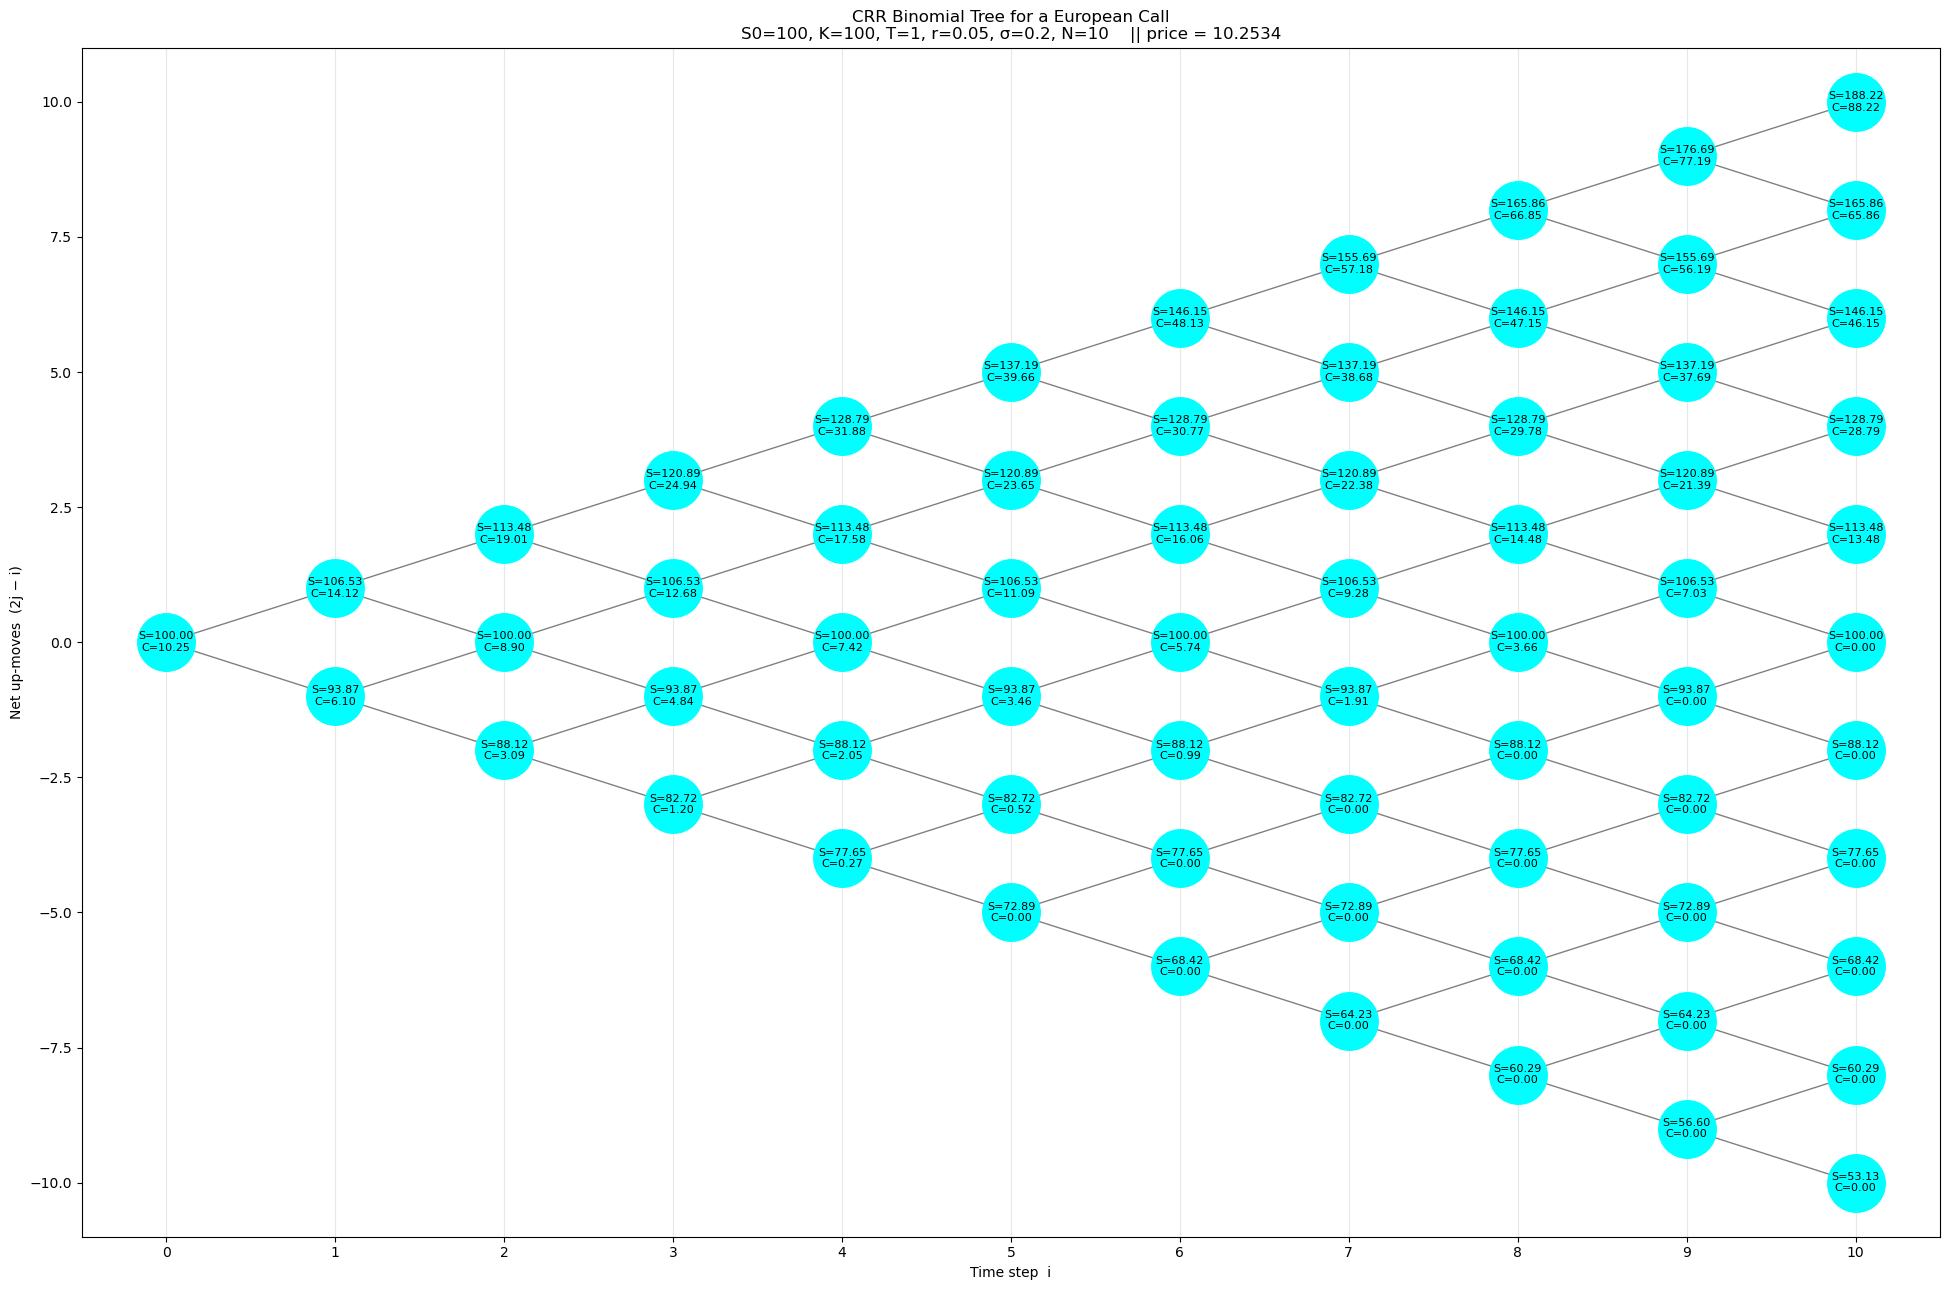

In [30]:
S0, K, T, r, sigma, N = 100., 100., 1., 0.05, 0.2, 10
 
price, stock_tree, option_tree = crr_european_call(S0, K, T, r, sigma, N)
 
print(f"CRR  ({N} steps) European call price = {price:.4f}")
title = (f"CRR Binomial Tree for a European Call\n"
             f"S0={S0:g}, K={K:g}, T={T:g}, r={r:g}, σ={sigma:g}, N={N}   "
             f" || price = {price:.4f}")
plot_binomial_tree(stock_tree, option_tree, N, title=title)
plt.show()


Delta-hedging simulation along the path
step  move          S     Delta      bank B     Pi=ΔS+B    option C        error
----------------------------------------------------------------------------------
   0     —   100.0000    0.6337    -53.1149     10.2534     10.2534    +0.00e+00
   1    up   106.5288    0.7495    -65.7170     14.1244     14.1244    +3.55e-15
   2  down   100.0000    0.6193    -53.0292      8.9017      8.9017    +0.00e+00
   3  down    93.8713    0.4521    -37.5966      4.8404      4.8404    -8.88e-15
   4  down    88.1182    0.2641    -21.2195      2.0511      2.0511    -2.22e-15
   5    up    93.8713    0.3995    -34.0397      3.4640      3.4640    -8.44e-15
   6  down    88.1182    0.1711    -14.0863      0.9949      0.9949    -6.66e-16
   7  down    82.7177    0.0000      0.0000      0.0000      0.0000    +1.78e-15
   8    up    88.1182    0.0000      0.0000      0.0000      0.0000    +1.79e-15
   9  down    82.7177    0.0000      0.0000      0.0000      0.000

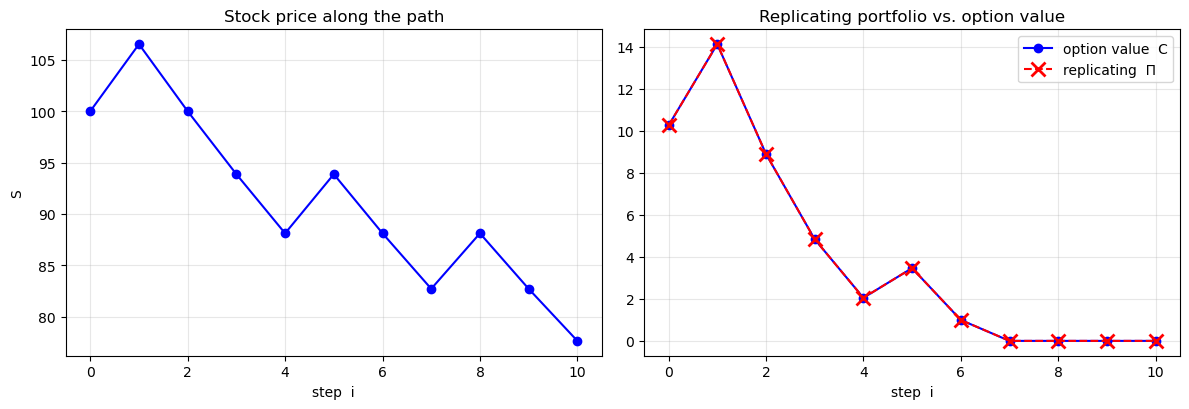

In [17]:
from scipy.stats import bernoulli
N = 10
path = bernoulli.rvs(.5, size=N)
moves = " ".join("up" if x else "down" for x in path)
print("\n" + "=" * 82)
print(f"Delta-hedging simulation along the path")
print("=" * 82)
table, _ = simulate_delta_hedge(S0, K, T, r, sigma, N, path=path)
print_hedge_table(table, path)
 
final = table[-1]
print(f"\nAt maturity:  Call payoff = {final['option']:.4f},  "
          f"replicating portfolio = {final['portfolio']:.4f}  "
          f"(error {final['portfolio'] - final['option']:+.2e})")
 
plot_hedge_simulation(table, path)
plt.show()

## Technical note: convergence as time steps goes to zero. From discrete to continuous time


Convergence to Black-Scholes:


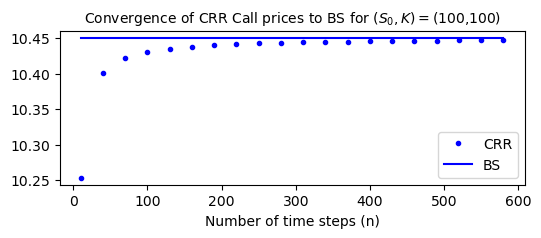

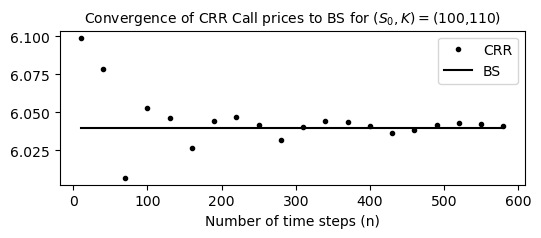

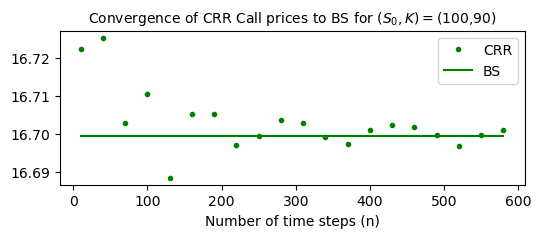

In [32]:
print("\nConvergence to Black-Scholes:")
nn = np.arange(10, 600, 30)


K_atm = S0
bs_callprice_atm = black_scholes_call(S0, K_atm, T, r, sigma)
crr_prices_atm = []
for n in nn:
    p, _, _ = crr_european_call(S0, K_atm, T, r, sigma, n)
    crr_prices_atm.append(p)

plt.figure(figsize=(6,2))
plt.plot(nn, crr_prices_atm, 'b.', label="CRR")
plt.plot(nn, [bs_callprice_atm for _ in nn], 'b', label="BS")
plt.legend(loc="best")
plt.title(r'Convergence of CRR Call prices to BS for $(S_0,K)=$(%.0f,%.0f)' %(S0,K_atm), fontsize=10)
plt.xlabel("Number of time steps (n)")
plt.show()

#######################################

K_otm = 1.1*S0
bs_callprice_otm = black_scholes_call(S0, K_otm, T, r, sigma)
crr_prices_otm = []
for n in nn:
    p, _, _ = crr_european_call(S0, K_otm, T, r, sigma, n)
    crr_prices_otm.append(p)

plt.figure(figsize=(6,2))
plt.plot(nn, crr_prices_otm, 'k.', label="CRR")
plt.plot(nn, [bs_callprice_otm for _ in nn], 'k', label="BS")
plt.legend(loc="best")
plt.title(r'Convergence of CRR Call prices to BS for $(S_0,K)=$(%.0f,%.0f)' %(S0,K_otm), fontsize=10)
plt.xlabel("Number of time steps (n)")
plt.show()

#######################################

K_itm = .9*S0
bs_callprice_itm = black_scholes_call(S0, K_itm, T, r, sigma)
crr_prices_itm = []
for n in nn:
    p, _, _ = crr_european_call(S0, K_itm, T, r, sigma, n)
    crr_prices_itm.append(p)

plt.figure(figsize=(6,2))
plt.plot(nn, crr_prices_itm, 'g.', label="CRR")
plt.plot(nn, [bs_callprice_itm for _ in nn], 'g', label="BS")
plt.legend(loc="best")
plt.title(r'Convergence of CRR Call prices to BS for $(S_0,K)=$(%.0f,%.0f)' %(S0,K_itm), fontsize=10)
plt.xlabel("Number of time steps (n)")
plt.show()

*Note*: This can be proved rigorously (of course!!). Not entirely trivial though....

# Moving to continuous time

### Radon-Nikodym derivative

#### Discrete case

Consider a discrete random variable $X$ over some (finite or countably infinite) set $\mathcal{X} = \{x_1,x_2,\ldots\}$ as well as two probability measures $\PP$ and $\QQ$ on $\mathcal{X}$, namely sequences $\{\PP(x)\}_{x\in\mathcal{X}}$ and $\{\QQ(x)\}_{x\in\mathcal{X}}$ such that $\sum_{x\in\mathcal{X}}\PP(x) = \sum_{x\in\mathcal{X}}\QQ(x) = 1$.
Then
$$
\EE^{\PP}[X]
= \sum_{x\in\mathcal{X}}x\PP(X=x)
= \sum_{x\in\mathcal{X}}x\frac{\PP(X=x)}{\QQ(X=x)}\QQ(X=x)
=: \EE^{\QQ}\left[\frac{\D\PP}{\D\QQ}X\right].
$$
The *likelihood ratio* $\frac{\D\PP}{\D\QQ}$ is called the Radon-Nikodym derivative.
For it to be well defined, we require that $\QQ(x)\ne 0$ for all $x$, or at least that $\QQ(x)= 0$ whenever $\PP(x)=0$. This corresponds to the two probabilities $\PP$ and $\QQ$ being *equivalent*.


Recall the following result:

**Proposition:**
A one-dimensional real random variable $Z$ is Gaussian with mean $\mu\in\RR$ and variance $\sigma^2>0$ if and only if the following identity holds for any $\alpha\in\RR$:
$$
\EE\left[\E^{\alpha Z}\right] = \exp\left\{\alpha\mu + \frac{\alpha^2\sigma^2}{2}\right\}.
$$

### Cameron-Martin-Girsanov Theorem

Consider a standard Brownian motion $(W_{t})_{t\geq 0}$ under a given probability measure $\PP$.
Fix some time horizon $T>0$. 
Since $W_T$ is Gaussian with mean $\mu_{\PP}=0$ and variance $\sigma_{\PP}^2=T$, then the above proposition yields, for any $\alpha\in\RR$,
$$
\EE^{\PP}\left[\E^{\alpha W_T}\right]
 = \exp\left\{\frac{\alpha^2 T}{2}\right\}.
$$

We are interested in studying how a change of measure changes the properties of $W$.

Consider a simple example, namely, for fixed given $T>0$, the Radon-Nikodym derivative
$$
\frac{\D\QQ}{\D\PP} = \exp\left\{-\gamma W_T - \frac{\gamma^2 T}{2}\right\},
$$
for some $\gamma\in\RR$.


In this case, we can perform the following computation, for any $\alpha\in\RR$:
\begin{align*}
\EE^{\QQ}\left[\E^{\alpha W_T}\right]
 & = \EE^{\PP}\left[\E^{\alpha W_T}\frac{\D\QQ}{\D\PP}\right]\qquad \text{(by definition of the change of measure)}\\
 & = \EE^{\PP}\left[\E^{\alpha W_T}\exp\left\{-\gamma W_T - \frac{\gamma^2 T}{2}\right\}\right]\qquad \text{(by definition of the Radon-Nikodym derivative)}\\
 & = \EE^{\PP}\left[\exp\left\{(\alpha-\gamma) W_T - \frac{\gamma^2 T}{2}\right\}\right]\\ 
 & = \exp\left\{-\frac{\gamma^2 T}{2}\right\}\EE^{\PP}\left[\E^{(\alpha-\gamma) W_T}\right]\\ 
 & = \exp\left\{-\frac{\gamma^2 T}{2}\right\}\exp\left\{\frac{1}{2}(\alpha-\gamma)^2 T\right\}\\ 
 & = \exp\left\{- \alpha\gamma T + \frac{\alpha^2 T}{2}\right\},
\end{align*}
so that, applying again the proposition above, we have that, under $\QQ$, 
the random variable $W_T$ is Gaussian with mean $\mu_{\QQ}=-\gamma T$ and variance $\sigma_{\QQ}^2=T$.


This can be extended to any $t\geq 0$, so that the change of measure $\PP\longrightarrow\QQ$ changes the drift of the Brownian motion $W$ from zero under $\PP$ to $-\gamma t$ under $\QQ$.


**Remark:** As a mnemotechnic trick, 
$$
\EE^{\PP}[Z] = \int Z\D\PP = \int Z\frac{\D\PP}{\D\QQ}\D\QQ = \EE^{\QQ}\left[Z\frac{\D\PP}{\D\QQ}\right].
$$

The above can be formalised as follows:

**Theorem [Cameron-Martin (1940s) - Girsanov (1960s)]**
Given a standard Brownian motion $(W^{\PP}_{t})_{t\geq 0}$ under $\PP$ and a process $(\gamma_{t})_{t\geq 0}$ satisfying the (Novikov) condition
$$
\EE^{\PP}\left[\exp\left\{\frac{1}{2}\int_{0}^{T}\gamma_t^2 \D t\right\}\right] < \infty,
$$
there exists a probability measure $\QQ$ *equivalent* to $\PP$ such that the process $(W^{\QQ}_{t})_{t\geq 0}$ defined by
$$
W^{\QQ}_{t} := W^{\PP}_t + \int_{0}^{t}\gamma_s \D s
$$
is a standard Brownian motion under $\QQ$.
The two measures $\PP$ and $\QQ$ are related via the Radon-Nikodym derivative
$$
\frac{\D\QQ}{\D\PP} = \exp\left\{-\int_{0}^{t}\gamma_s\D W^{\PP}_s - \frac{1}{2}\int_{0}^{t}\gamma_s^2 \D s\right\}.
$$

### Simple example

As an example, consider $X_{t} = \mu t + \sigma W^{\PP}_{t}$, for some Brownian motion $W^{\PP}$ under $\PP$, where $\mu\in\RR$ and $\sigma>0$. 
We can then write
$$
X_{t} = \sigma\left(\frac{\mu}{\sigma}t + W^{\PP}_{t}\right) =: \sigma W^{\QQ}_{t},
$$
where we define
$$
W^{\QQ}_{t} := \frac{\mu}{\sigma}t + W^{\PP}_{t}, 
$$
namely taking $\gamma_t = \frac{\mu}{\sigma}$ in the Cameron-Martin-Girsanov theorem.
The Novikov condition is trivially satisfied since $\gamma_t$ is constant, so that $W^{\QQ}$ is a Brownian motion under $\QQ$.
This implies in particular that, for any $t\geq 0$,
$$
\EE^{\QQ}[X_t] = \EE^{\QQ}\left[\sigma W^{\QQ}_{t}\right] = 0,
$$
so that $X$ is a martingale under $\QQ$, while it is clearly not so under $\PP$ since
$$
\EE^{\PP}[X_t] = \EE^{\PP}\left[\mu t + \sigma W^{\PP}_{t}\right] = \mu t.
$$

### Black-Scholes example

We now follow the original Black-Scholes paper and consider a stock price process following, under the (historical) measure $\PP$ the stochastic dynamics
$$
\boxed{\frac{\D S_t}{S_t} = \mu \D t + \sigma \D W^{\PP}_t,\quad\text{under }\PP},
$$
starting from $S_0>0$, with $\mu\in\RR$ and $\sigma>0$, where $W^{\PP}$ is a standard one-dimensional $\PP$-Brownian motion.
We further consider a constant instantaneous risk-free rate $r$,
and denote the discounted stock price $\widetilde{S}_{t} :=\E^{-rt}S_t$.
Ito's formula gives us
\begin{align*}
\D \widetilde{S}_{t} & = \E^{-rt}\D S_t - r\E^{-rt}S_t \D t\\
 & = \E^{-rt}S_t\Big(\mu \D t + \sigma \D W^{\PP}_t\Big) - r\E^{-rt}S_t \D t\\
 & = \widetilde{S}_t\Big(\mu \D t + \sigma \D W^{\PP}_t\Big) - r\widetilde{S} \D t,
\end{align*}
equivalently
$$
\frac{\D \widetilde{S}_{t}}{\widetilde{S}_{t}}
= (\mu-r) \D t + \sigma \D W^{\PP}_t
$$
With an analysis analogous to the one in the previous example, write
$$
\frac{\D \widetilde{S}_{t}}{\widetilde{S}_{t}}
 = \sigma\left(\frac{\mu-r}{\sigma}t + W^{\PP}_{t}\right) = \sigma W^{\QQ}_{t},
$$
where we define
$$
W^{\QQ}_{t} := \frac{\mu-r}{\sigma}t + W^{\PP}_{t}, 
$$
namely taking $\gamma_t = \frac{\mu-r}{\sigma}$ in the Cameron-Martin-Girsanov theorem.
The quantity $\gamma_t$ (constant here) is called *the market price of risk*.
The Novikov condition is trivially satisfied since $\gamma_t$ is constant, so that $W^{\QQ}$ is a Brownian motion under $\QQ$ defined via
$$
\frac{\D\QQ}{\D\PP} := 
\exp\left\{- \int_{0}^{T}\frac{\mu-r}{\sigma}\D W^{\PP}_s
-\frac{1}{2}\int_{0}^{T}\left(\frac{\mu-r}{\sigma}\right)^2\D s\right\}.
$$
The dynamics of the original process $S_t = \E^{rt}\widetilde{S}_t$ under $\QQ$ thus reads, again using Ito's formula,
$$
\D S_t = \E^{rt}\D\widetilde{S}_t + r\E^{rt}\widetilde{S}_t\D t
= \E^{rt}\sigma\widetilde{S}_t\D W^{\QQ}_t  + r\E^{rt}\widetilde{S}_t\D t,
$$
equivalently
$$
\boxed{\frac{\D S_t}{S_t} = r\D t + \sigma \D W^{\QQ}_t,\qquad\text{under }\QQ.}
$$
This can be solved explicitly via Ito's formula as
$$
S_{t} = S_{0}\exp\left\{\left(r-\frac{\sigma^2}{2}\right)t + \sigma W^{\QQ}_t\right\},
$$
This implies in particular that, for any $t\geq 0$,
$$
\EE^{\QQ}\left[\widetilde{S}_t\right] = \widetilde{S}_{0},
$$
so that the discounted stock price process $\widetilde{S}$ is a true martingale under $\QQ$.

Recall the following:

**Theorem [Fundamental Theorem of Asset Pricing]: A model $M$ is called arbitrage-free (i.e. there does not exist any admissible arbitrage strategy) if 
there exists an equivalent probability measure $\QQ$ under which the model is a martingale, i.e. $\EE^{\QQ}[M_t|\mathcal{F}_{s}] = M_s$, for all $0\leq s\leq t$.**


This implies that the price of a derivative on $S$ with payoff $\Phi(S_T)$ at maturity $T>0$ is given by (since $S_T = \E^{rT}\widetilde{S}_{T}$)
$$
\Call_{0} = \EE^{\QQ}\left[\E^{-rT}\Phi(\E^{rT}\widetilde{S}_{T})\right].
$$
In the case of a European Call option with maturity $T$ and strike $K$, then
$\Phi(S_T) = \max(S_T-K,0)$, so that
$$
\Call_{0} = \EE^{\QQ}\left[\E^{-rT}\max(\E^{rT}\widetilde{S}_{T}-K, 0)\right]
 = \E^{-rT}\EE^{\QQ}\left[\max(S_{T}-K, 0)\right].
$$


## $\PP$ and $\QQ$ in the real world? Example with Black-Scholes

Consider the Log-Normal dynamics for the stock price under the historical measure $\PP$:
$$
\frac{\D S_t}{S_t} = \mu \D t + \sigma \D W^{\PP}_t,
$$
starting from $S_0>0$, with $\mu\in\RR$ and $\sigma>0$, where $W^{\PP}$ is a standard one-dimensional Brownian motion.
Here $\mu$ represents the (constant) drift and can be estimated from historical data.
Indeed, by Ito formula, we can write, for any $0\leq u\leq t$,
$$
\log\left(\frac{S_t}{S_u}\right) = \left(\mu-\frac{\sigma^2}{2}\right)(t-u) + \sigma (W^{\PP}_t - W^{\PP}_u),
$$
and therefore 
\begin{align*}
\EE^{\PP}\left[\log\left(\frac{S_t}{S_u}\right)\right] & = \left(\mu-\frac{\sigma^2}{2}\right)(t-u),\\
\VV^{\PP}\left[\log\left(\frac{S_t}{S_u}\right)\right] & = \sigma^2(t-u).
\end{align*}

Consider the log-returns daily time series $(X_{t_i})_{i=1,\ldots, n}$ where
$$
X_{t_i} := \log\left(\frac{S_{t_{i}}}{S_{t_{i-1}}}\right).
$$
Assuming Log-Normal dynamics, since the Gaussian increments are independent, 
then, with $\Delta = 1$ day,
a statistical estimator for the mean $(\mu-\frac{\sigma^2}{2})\Delta$ reads
$$
\widehat{m} = \frac{1}{n}\sum_{i=1}^{n}X_{t_{i}}
$$
and an unbiased statistical estimator for the variance $\sigma^2 \Delta$ reads
$$
\widehat{s}^2 = \frac{1}{n-1}\sum_{i=1}^{n}\left(X_{t_{i}} - \widehat{m}\right)^2.
$$

We then deduce that
$$
\widehat{\mu} := \frac{\widehat{m}}{\Delta} + \frac{\widehat{\sigma}^2}{2}
\qquad\text{and}\qquad
\widehat{\sigma}^2 := \frac{\widehat{s}^2}{\Delta}.
$$

In [33]:
import pandas as pd
pd.core.common.is_list_like = pd.api.types.is_list_like
from datetime import datetime
%matplotlib inline
import matplotlib.pyplot as plt
import random
import yfinance as yf  
import numpy as np

In [34]:
start, end = '2000-01-01', '2023-01-20'
ticker = 'SPY'
df = yf.download(ticker,start, end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2000-01-03,91.367561,93.134446,90.385959,93.134446,8164300
2000-01-04,87.794510,90.503732,87.725798,90.169987,8089800
2000-01-05,87.951553,88.913523,86.223934,87.912289,12177900
2000-01-06,86.538033,88.893877,86.538033,87.715955,6227200
2000-01-07,91.563843,91.563843,87.990811,88.147868,8066500


In [35]:
def estimate_gbm_params(prices, dt=1./252.):
    """
    Estimate (mu, sigma^2) of a Geometric Brownian Motion from a price series.

    Parameters
    ----------
    prices : array-like or pd.Series
        Daily price series (S_t). Must be strictly positive.
    dt : float, default 1/252
        Time step between consecutive observations, in the time unit
        you want for mu and sigma^2. Use 1/252 for annualized parameters
        from business-daily data, 1/365 for calendar-daily, or 1 for
        per-step (daily) parameters.

    Returns
    -------
    dict with keys 'mu', 'sigma2', 'sigma', and standard errors.
    """
    S = np.asarray(prices, dtype=float)
    if np.any(S <= 0):
        raise ValueError("Prices must be strictly positive.")


    # Log-returns log(S_{t_i} / S_{t_{i-1}})
    log_ret = np.diff(np.log(S))

    n = len(log_ret)
    if n < 2:
        raise ValueError("Need at least 2 returns to estimate parameters.")

    m_hat = log_ret.mean()             # estimates (mu - sigma^2/2) * dt
    s2_hat = log_ret.var(ddof=1)       # estimates sigma^2 * dt

    sigma2 = s2_hat / dt
    mu     = m_hat / dt + 0.5 * s2_hat

    # Standard errors (asymptotic, under the GBM/i.i.d. Gaussian assumption)
    se_m   = np.sqrt(s2_hat / n)             # Standard error of the sample mean
    se_s2  = s2_hat * np.sqrt(2. / (n - 1))  # Standard error of sample variance (Gaussian)
    se_sigma2 = se_s2 / dt
    se_mu     = np.sqrt((se_m / dt)**2 + (0.5 * se_sigma2)**2)

    return {
        "mu": mu,
        "sigma": np.sqrt(sigma2),
        "se_mu": se_mu,
        "se_sigma2": se_sigma2,
        "n_returns": n,
        "dt": dt,
    }

#### Test on real SPX time series

In [36]:
my_time_series = np.resize(df["Close"].values, len(df["Close"]))
out = estimate_gbm_params(my_time_series, dt=1./252.)

print(f"mu     = {out['mu']:.4f} (Standard Error: {out['se_mu']:.4f})")
print(f"sigma  = {out['sigma']:.4f} (Standard Error: {out['se_sigma2']:.4f})")

mu     = 0.0612 (Standard Error: 0.0414)
sigma  = 0.1986 (Standard Error: 0.0007)


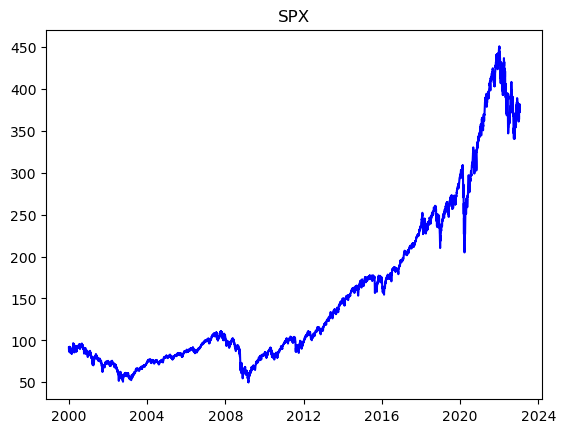

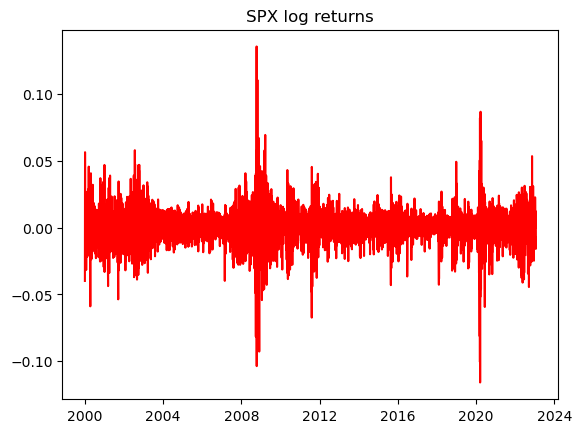

In [37]:
log_ret = np.diff(np.log(my_time_series))
plt.plot(df.index, df["Close"], 'b')
plt.title("SPX")
plt.show()
plt.plot(df.index[1:], log_ret, 'r')
plt.title("SPX log returns")
plt.show()

## A note on option pricing

Consider a European Call option price on an asset price $S$, assuming no interest rate and no dividend for simplicity, assumed to be a true martingale under a given measure $\QQ$, so that
\begin{align*}
\Call = \EE^{\QQ}\Big[(S_T - K)_{+}\Big]
 & = \EE^{\QQ}\Big[(S_T - K)\mathbf{1}_{S_T\geq K}\Big]\\
 & = \EE^{\QQ}\Big[S_T\mathbf{1}_{S_T\geq K} - K\mathbf{1}_{S_T\geq K}\Big]\\
 & = \EE^{\QQ}\Big[S_T\mathbf{1}_{S_T\geq K}\Big] - \EE^{\QQ}\Big[K\mathbf{1}_{S_T\geq K}\Big]\\
 & = S_0\EE^{\QQ}\left[\frac{S_T}{S_0}\mathbf{1}_{S_T\geq K}\right] - K\QQ\Big(S_T\geq K\Big)\\
 & = S_0\EE^{\QQ^{S}}\left[\mathbf{1}_{S_T\geq K}\right] - K\QQ\Big(S_T\geq K\Big)\\
 & = S_0\QQ^{S}\Big(S_T\geq K\Big) - K\QQ\Big(S_T\geq K\Big),
\end{align*}
where the Radon-Nikodym derivative is given by
$$
\frac{\D\QQ^{S}}{\D\QQ} = \frac{S_T}{S_0}.
$$
This shows that the price of the European Call option can be interpreted as a difference of two probabilities:
- $\QQ\Big(S_T\geq K\Big)$ is the probability of finishing in the money under $\QQ$, the *risk-neutral measure*;
- $\QQ^{S}\Big(S_T\geq K\Big)$ is the probability of finishing in the money under $\QQ^{S}$, the *Share measure*.

# Finding $\QQ$

For pricing purposes, we usually start from $\QQ$ and forget about $\PP$ altogether, namely we consider dynamics of the form
$$
\frac{\D S_t}{S_t} = r \D t + \sigma_{t} \D W^{\QQ}_t
$$
under some (risk-neutral) probability measure $\QQ$ such that the discounted stock price process is a martingale $(\E^{-rt}S_{t})$ under $\QQ$, namely such that
$$
\EE^{\QQ}\left[\E^{-rt}S_{t} | \mathcal{F}_{u}\right] = \E^{-ru}S_{u},
\qquad\text{for all }0\leq u\leq t,
$$
where $(\mathcal{F}_{t})_{t\geq 0}$ denotes the filtration at time $t$ (amount of information generated by the process up to time $t$).

**Notes:**
- The process $(\sigma_{t})_{t\geq 0}$ can be constant as in the Black-Scholes model or stochastic itself (in stochastic volatility models)
- In practice, the risk-free rate is not constant and depends on time, and is in fact stochastic itself.

To price a European Call option with maturity $T$, one must match the currency and the maturity and consider the corresponding $T$ Treasury yield.

Given many strikes, one can also use Put-Call parity to estimate (by linear regression) the discount factor.

# Further (advanced) questions

- There may in fact exist (infinitely) many equivalent martingale measures, as in the case of incomplete markets such as stochastic volatility models.
- Trinomial trees also exist, but more specifications are needed as they give rise to incomplete markets (hence infinite number of equivalent martingale measures).
- *Equity premium puzzle* consists in actually estimating the market price of risk $\frac{\mu-r}{\sigma}$ and is notoriously hard (decades of Financial Economics research)
- Change of measure is also used in:
  + Fixed Income, in particular the *T-forward measure*, fundamental to compute caps, floors, swaptions, and the *Swap measure*.
  +  Importance sampling in Monte Carlo to compute probabilities of "rare events". The idea is to re-weigh the probabilities to make these rare events more likely. Important in for deep-out-of-the-money option pricing, rare default events, barrier options, tail-risk estimation.

# A more involved example: Quanto adjustment

Consider a foreign asset $S_t$ (Eurostoxx index, quoted in EUR) with payoff settled in domestic currency (GBP). 
In a Quanto contract, the foreign-currency price is paid in domestic currency at a pre-specified FX rate (often $1$), so the holder is exposed to the foreign asset but not to the realised exchange rate.

We use the following notation:
- $S_t$: foreign asset price, denominated in foreign currency (EUR).
- $X_t$: exchange rate, expressed as units of domestic per foreign (GBP per EUR).
- $r_d, r_f$: domestic and foreign risk-free rates, assumed constant.
- no dividend yield on $S$.
- $\sigma_S, \sigma_X$: volatilities of $S$ and $X$.
- $\rho$: instantaneous correlation between the Brownian motions driving $S$ and $X$.

We write the foreign and domestic risk-neutral measures by $\QQ^{f}$ and $\QQ^{d}$.

We assume that, under $\QQ^{f}$, the asset satisfies
$$
\frac{\D S_t}{S_t} = r_f \D t + \sigma_S\D W_t^{S,f}.
$$
Under $\QQ^{d}$, standard FX no-arbitrage implies that
$$
\frac{\D X_t}{X_t} = (r_d - r_f)\D t + \sigma_X\D W_t^{X,d},
$$
with $\D \langle W^{S,\cdot}, W^{X,\cdot}\rangle_{t} = \rho\D t$.

This can be proved as follows:
Note that $X$ itself is not a traded asset. 
Consider the strategy of converting GBP to EUR at time $t_0$, 
buy the EUR amount and hold it (holding one unit of foreign currency).

The EUR value at time $t$ of this position is $\E^{r_f t}$ and its GBP value is therefore $A_{t}:=\E^{r_{f}t}X_t$, which is tradable.
By the **Fundamental Theorem of Asset Pricing**, under the measure $\QQ^d$,
the discounted price
$$
M_{t} := \E^{-r_d t}A_t = X_t \E^{(r_f - r_d)t}
$$
must be a $\QQ^d$-martingale. Assume some dynamics under $\QQ^d$ of the form
$$
\frac{\D X_t}{X_t} = \mu_{X}^{d}\D t + \sigma_{X}\D W_{t}^{X,d}.
$$
Ito's formula then yields
$$
\frac{\D M_t}{M_t} = \left(\mu_{X}^{d}+r_f-r_d\right)\D t + \sigma_{X}\D W_{t}^{X,d}.
$$
To ensure martingality, the drift must be zero, proving the claim.

To price a GBP-denominated payoff we need the dynamics of $S$ under $\QQ^{d}$, since
the pricing formula is
$$
V_0 = \E^{-r_d T} \EE^{\QQ^{d}}\Big[\text{payoff}_T\Big].
$$

The product $Y_t := S_t X_t$ is a tradable in domestic currency: it is the GBP
value of one share of the foreign asset. As such, viewed as a domestic asset
paying dividend yield $q$, no-arbitrage requires that under $\QQ^{d}$ its drift be
$r_d$.

Posit unknown $\QQ^{d}$-dynamics for $S$ of the form
$$
\frac{\D S_t}{S_t} = \mu_S^{d}\D t + \sigma_S\D W_t^{S,d},
$$
where $\mu_S^{d}$ is to be determined.
Then
$$
\frac{\D Y_t}{Y_t}
    = \frac{\D S_t}{S_t} + \frac{\D X_t}{X_t}
      + \frac{\D S_t}{S_t} \frac{\D X_t}{X_t},
$$
which expands to
$$
\frac{\D Y_t}{Y_t}
    = \Big(\mu_S^{d} + (r_d - r_f) + \rho \sigma_S \sigma_X\Big)\D t
      + \sigma_S \D W_t^{S,d} + \sigma_X\D W_t^{X,d}.
$$
The no-arbitrage condition on $Y$ requires
$$
\mu_S^{d} + (r_d - r_f) + \rho \sigma_S \sigma_X = r_d - q,
$$
and solving for $\mu_S^{d}$ yields the central result:
$$
\boxed{\mu_S^{d} = r_f - q - \rho\sigma_S\sigma_X}
$$
Hence under the domestic risk-neutral measure,
$$
\frac{\D S_t}{S_t} = \Big(r_f - q - \rho\sigma_S\sigma_X\Big) \D t
             + \sigma_S \D W_t^{S,d}.
$$
The term $-\rho\sigma_S\sigma_X$ is the *quanto drift adjustment*.

**Cameron-Martin-Girsanov perspective**

The same shift can be derived directly from Girsanov's theorem. Changing
numeraire from the foreign money-market account to the domestic one corresponds
to a Radon-Nikodym density that depends on the FX dynamics. 
$$
\left.\frac{\D \QQ^{d}}{\D \QQ^{f}}\right|_{\mathcal{F}_t}
= \exp\left\{-\frac{1}{2}\int_{0}^{t}\sigma_X^{2}\D s + \int_{0}^{t}\sigma_X \D W_s^{X,f}\right\}.
$$
By Cameron-Martin-Girsanov theorem, the Brownian motion driving $S$ undergoes the shift
$$
W_t^{S,d} = W_t^{S,f} - \rho \sigma_X t,
$$
so that, substituting into above,
$$
\frac{\D S_t}{S_t} = (r_f - q)\D t + \sigma_S \Big(\D W_t^{S,d} + \rho\sigma_X\D t\Big),
$$
which simplifies to
$$
\frac{\D S_t}{S_t} = \Big(r_f - q + \rho\sigma_S\sigma_X\Big)\D t + \sigma_S \D W_t^{S,d}.
$$

*Pricing a vanilla quanto option*

Clearly, $S_T$ is Log-Normal under $\QQ^{d}$ with
log-mean $\log(S_0) + (\mu_S^{d} - \frac{1}{2}\sigma_S^{2})T$ and log-variance
$\sigma_S^{2} T$. A European quanto call paying $\max(S_T - K, 0)$ in domestic
currency has value
$$
\Call_0 = \E^{-r_d T} \EE^{\QQ^{d}}\Big[\max(S_T - K, 0)\Big],
$$
which evaluates to a Black-Scholes-type formula:
$$
\boxed{\Call_0 = \E^{-r_d T}\left[S_0\E^{(r_f - \rho\sigma_S\sigma_X) T}\mathcal{N}(d_+) - K\mathcal{N}(d_-)\right]}
$$
where $\mathcal{N}(\cdot)$ denotes the Gaussian cumulative distribution function and 
$$
d_{\pm} := \frac{\log(S_0 / K) + \Big(r_f - \rho\sigma_S\sigma_X \pm \frac{1}{2}\sigma_S^{2}\Big)T}{\sigma_S\sqrt{T}}.
$$

# Application to Importance sampling

Fix a probability measure $\PP$, and consider the one-dimensional stochastic differential equation
$$
\D X_t = b(X_t) \D t + \sigma(X_t) \D W^{\PP}_t, \qquad X_0 = x_0.
$$
The goal is to compute $\EE^{\PP}[\varphi(X_T)]$ numerically, say by Monte Carlo. 
However, if the event is rare under $\PP$, then naive Monte Carlo may have a very large variance, thus requiring a huge number of samples.
Importance sampling works by shifting this expectation to a new probability measure $\QQ$ by Girsanov, making the event less rare.

Consider a (sufficiently regular) function $(t,x)\mapsto \gamma(t,x)$ and set
$$
W^{\QQ}_t := W^{\PP}_t + \int_{0}^{t}\gamma(u,X_u)\D u.
$$
Then $W^{\QQ}$ is a $\QQ$-Brownian motion with Radon-Nikodym derivative
$$
\left.\frac{\D\QQ}{\D\PP}\right|_{\mathcal{F}_T}
= \exp\left\{-\int_0^T \gamma(t,X_t) \D W^{\PP}_t  -  \frac{1}{2}\int_0^T \gamma(t,X_t)^2 \D t\right\},
$$
and therefore
\begin{align*}
\D X_t & = b(X_t) \D t + \sigma(X_t) \D W^{\PP}_t\\
 & = b(X_t) \D t + \sigma(X_t) \, \D \Big(W^{\QQ}_t - \int_{0}^{t}\gamma(u,X_u)\D u\Big)\\
 & = \Big(b(X_t) - \sigma(X_t) \gamma(t,X_t)\Big) \D t + \sigma(X_t) \D W_t^{\QQ}\\
\end{align*}
We further have that
$$
\EE^{\QQ}\Big[\varphi(X_T)\Big]  =  \EE^{\PP}\left[\varphi(X_T) \frac{\D\QQ}{\D\PP}\right]
\quad\text{or equivalently}\quad
\EE^{\PP}\Big[\varphi(X_T)\Big]  =  \EE^{\QQ}\left[\varphi(X_T) \frac{\D\PP}{\D\QQ}\right],
$$
with Radon-Nikodym derivative
$$
\frac{\D\QQ}{\D\PP}
 = \exp\left\{-\int_0^T \gamma(t,X_t) \D W_t^{\PP} - \frac{1}{2}\int_0^T \gamma(t,X_t)^2 \D t\right\}.
$$

#### Example
Consider the simple example with $b \equiv 0$ and $\sigma \equiv 1$.
In this case, $X_t = W_t$ under $\PP$.
We wish to estimate
$$
\PP(W_T > a), \quad\text{with }a = 4, T=1.
$$
This probability is roughly equal to $3.17 \times 10^{-5}$, so a naive Monte Carlo with $n = 10^5$ paths returns $0$ most of the time.

Consider now the shift $h(\cdot) \equiv -\frac{a}{T}$.
Under $\QQ$, then 
$$
\D X_t = \frac{a}{T}\D t + \D W_t^{\QQ},
$$
where $W_t^{\QQ} := W_{t}^{\PP} - \frac{at}{T}$
and the Radon-Nikodym derivative reads
$$
\frac{\D\QQ}{\D\PP} = \exp\left\{-\int_0^T h(t,X_t) \D W_t^{\PP} - \frac{1}{2}\int_0^T h(t,X_t)^2 \D t\right\}
 = \exp\left\{\frac{a}{T}W_T^{\PP} - \frac{a^{2} T}{2}\right\}.
$$
The desired probability can thus be computed as
\begin{align*}
\PP(W_T > a) = \EE^{\PP}\left[\mathbf{1}_{\{W_T > a\}}\right]
 & = \EE^{\QQ}\left[\mathbf{1}_{\{W_T > a\}}\frac{\D\PP}{\D\QQ}\right]\\
 & = \EE^{\QQ}\left[\mathbf{1}_{\{W_T > a\}}\exp\left\{-\frac{a}{T}W_T^{\PP} + \frac{a^{2} T}{2}\right\}\right].
\end{align*}

In [46]:
import numpy as np
from scipy.stats import norm

T, a = 1., 3.
nb_paths, nb_timesteps = 10000, 100
dt = T / nb_timesteps

# --- Monte Carlo under P
W_increments_P = np.random.normal(0., 1., (nb_paths, nb_timesteps)) * np.sqrt(dt)
X_T_P  = W_increments_P.sum(axis=1)
nb_hits_P = (X_T_P > a).astype(float)
proba_P, se_P = nb_hits_P.mean(), nb_hits_P.std(ddof=1) / np.sqrt(nb_paths)

# --- Monte Carlo under Q
W_increments_Q = np.random.normal(0., 1., (nb_paths, nb_timesteps)) * np.sqrt(dt) + (a/T) * dt
X_T_Q  = W_increments_Q.sum(axis=1)
RN_deriv = np.exp(-(a/T) * X_T_Q + 0.5 * a**2 * T) ## Radon-Nikodym derivative
est    = (X_T_Q > a).astype(float) * RN_deriv
proba_Q, se_Q = est.mean(), est.std(ddof=1)/np.sqrt(nb_paths)

proba_exact = 1 - norm.cdf(a / np.sqrt(T))
print(f"Exact probability  : {proba_exact:.3e}")
print(f"Monte Carlo estimate under P: {proba_P:.3e}  (Standard error: {se_P:.2e})")
print(f"Monte Carlo estimate under Q: {proba_Q:.3e}  (Standard error: {se_Q:.2e})")

Exact probability  : 1.350e-03
Monte Carlo estimate under P: 1.200e-03  (Standard error: 3.46e-04)
Monte Carlo estimate under Q: 1.384e-03  (Standard error: 2.48e-05)


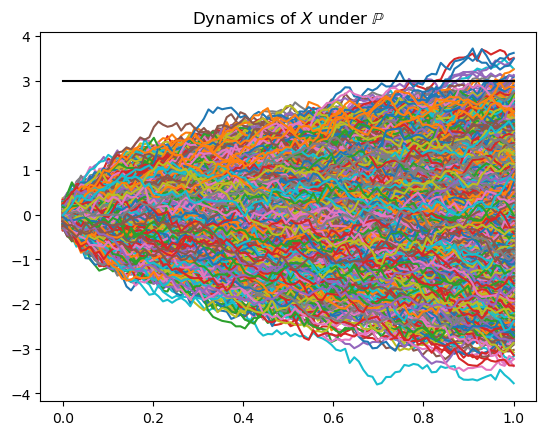

In [47]:
tt = np.linspace(0., T, nb_timesteps)
cumsum_P = np.cumsum(W_increments_P, axis=1)
cumsum_Q = np.cumsum(W_increments_Q, axis=1)
for i in range(nb_paths):
    plt.plot(tt, cumsum_P[i, :])

plt.plot(tt, [a for _ in tt], 'k')
plt.title(r'Dynamics of $X$ under $\mathbb{P}$')
plt.show()

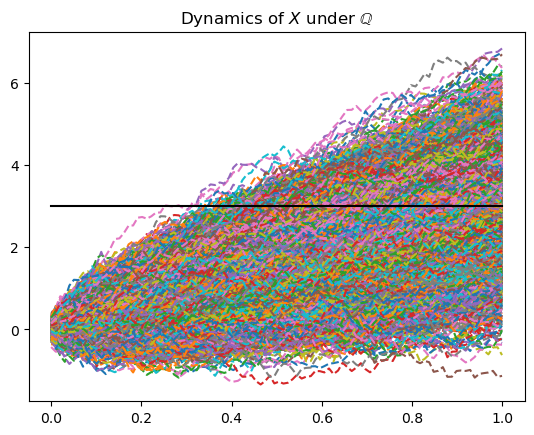

In [48]:
tt = np.linspace(0., T, nb_timesteps)
cumsum_Q = np.cumsum(W_increments_Q, axis=1)
for i in range(nb_paths):
    plt.plot(tt, cumsum_Q[i, :], '--')

plt.plot(tt, [a for _ in tt], 'k')
plt.title(r'Dynamics of $X$ under $\mathbb{Q}$')
plt.show()